# Probability Assignment

Module 13 — simulations for coins, dice, Bayes, discrete/continuous RVs, and CLT.


In [11]:
import random
import numpy as np
import matplotlib.pyplot as plt


## 1a. Coin toss (10,000 times)

Just flip a lot of times and see how close we get to 50-50.


P(heads) = 0.5009
P(tails) = 0.4991


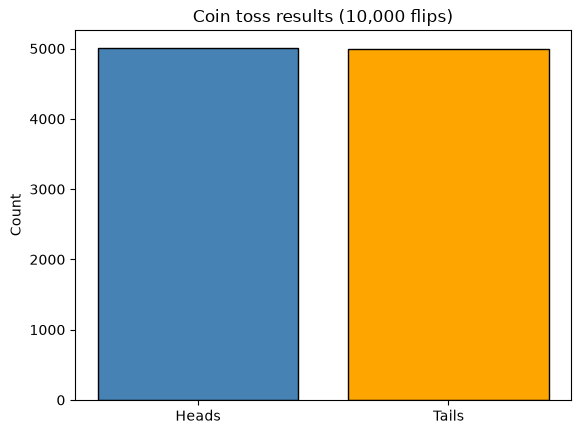

In [12]:
n = 10000
heads = 0
tails = 0

for _ in range(n):
    if random.choice(["H", "T"]) == "H":
        heads += 1
    else:
        tails += 1

print("P(heads) =", heads / n)
print("P(tails) =", tails / n)

# bar chart of the results
plt.bar(["Heads", "Tails"], [heads, tails], color=["steelblue", "orange"], edgecolor="black")
plt.ylabel("Count")
plt.title("Coin toss results (10,000 flips)")
plt.show()



## 1b. Two dice, sum = 7

Roll two dice many times, count how often they add up to 7. Theory says 6/36 = 1/6.


In [13]:
trials = 10000
success = 0

for _ in range(trials):
    d1 = random.randint(1, 6)
    d2 = random.randint(1, 6)
    if d1 + d2 == 7:
        success += 1

print("P(sum = 7) ≈", success / trials)
print("theory:", 6 / 36)


P(sum = 7) ≈ 0.1678
theory: 0.16666666666666666


## 2. At least one 6 in 10 rolls

Run many trials of 10 rolls each. Count trials that got at least one six.


In [14]:
def at_least_one_six(n_trials=10000, n_rolls=10):
    success = 0
    for _ in range(n_trials):
        rolls = [random.randint(1, 6) for _ in range(n_rolls)]
        if 6 in rolls:
            success += 1
    return success / n_trials

est = at_least_one_six()
print("estimate:", est)
print("theory:  ", 1 - (5/6)**10)


estimate: 0.8377
theory:   0.8384944171101543


## 3. Bag of balls (with replacement)

5 red, 7 green, 8 blue. Draw 1000 times putting the ball back each time.

Want P(red | previous was blue). Since draws are independent that should just be P(red) = 5/20.


In [15]:
bag = ["R"] * 5 + ["G"] * 7 + ["B"] * 8
draws = [random.choice(bag) for _ in range(1000)]

# look at consecutive pairs
blue_then_red = 0
prev_was_blue = 0

for i in range(1, len(draws)):
    if draws[i - 1] == "B":
        prev_was_blue += 1
        if draws[i] == "R":
            blue_then_red += 1

p_red_given_blue = blue_then_red / prev_was_blue
print("P(red | prev blue) ≈", p_red_given_blue)
print("P(red) theory      =", 5 / 20)


P(red | prev blue) ≈ 0.27602905569007263
P(red) theory      = 0.25


### Bayes check

Using A = red this draw, B = blue on the previous draw:

\[
P(A|B) = \frac{P(B|A)\,P(A)}{P(B)}
\]

Why this becomes "trivial" here: we put the ball back each time, so draw \(i\) doesn't change the bag for draw \(i+1\). Knowing the previous ball was blue tells you nothing about the next draw — the two events are independent.

Independence means \(P(A \cap B) = P(A)P(B)\), which is the same as \(P(A|B) = P(A)\) and \(P(B|A) = P(B)\).

Plug that into Bayes:

\[
P(A|B) = \frac{P(B)\,P(A)}{P(B)} = P(A)
\]

So the conditional probability collapses to the plain (marginal) probability of red, which is \(5/20 = 0.25\). The simulation below should get the same number from both the direct count and the Bayes formula.


In [16]:
# empirical probs from the sequence of pairs
n_pairs = len(draws) - 1

# P(A): current is red
p_A = sum(1 for i in range(1, len(draws)) if draws[i] == "R") / n_pairs

# P(B): previous is blue
p_B = prev_was_blue / n_pairs

# P(B|A): previous blue given current red
a_and_prev_blue = sum(
    1 for i in range(1, len(draws)) if draws[i] == "R" and draws[i - 1] == "B"
)
p_B_given_A = a_and_prev_blue / sum(1 for i in range(1, len(draws)) if draws[i] == "R")

bayes = (p_B_given_A * p_A) / p_B
print("direct P(A|B):", p_red_given_blue)
print("Bayes P(A|B): ", bayes)
print("(should be close to each other and to 0.25)")


direct P(A|B): 0.27602905569007263
Bayes P(A|B):  0.27602905569007263
(should be close to each other and to 0.25)


## 4. Discrete random variable

Sample from {1,2,3} with probs 0.25, 0.35, 0.4 — then mean / var / std.


In [17]:
vals = [1, 2, 3]
probs = [0.25, 0.35, 0.4]

sample = np.random.choice(vals, size=1000, p=probs)

print("mean:", np.mean(sample))
print("var: ", np.var(sample))
print("std: ", np.std(sample))
print("theory mean:", 1*0.25 + 2*0.35 + 3*0.4)


mean: 2.146
var:  0.6446839999999999
std:  0.8029221631017541
theory mean: 2.1500000000000004


## 5. Exponential distribution (mean = 5)

2000 samples. Histogram + PDF overlay. In numpy, scale = mean.


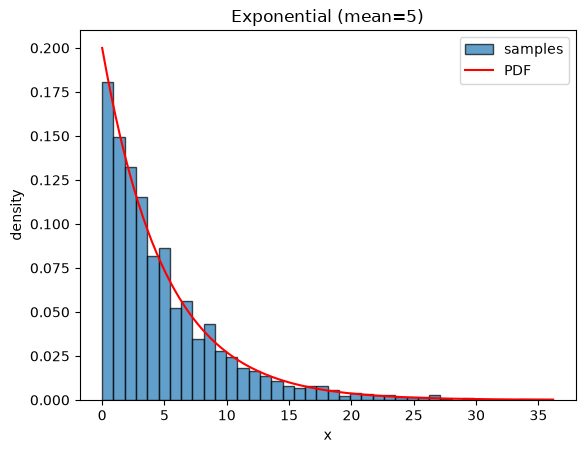

In [18]:
data = np.random.exponential(scale=5, size=2000)

x = np.linspace(0, data.max(), 200)
pdf = (1 / 5) * np.exp(-x / 5)

plt.hist(data, bins=40, density=True, edgecolor="black", alpha=0.7, label="samples")
plt.plot(x, pdf, color="red", label="PDF")
plt.xlabel("x")
plt.ylabel("density")
plt.title("Exponential (mean=5)")
plt.legend()
plt.show()


## 6. Central Limit Theorem

Generate 10,000 uniforms for the left plot. For the sample means: each of the 1000 trials draws a **fresh** sample of size 30 from uniform (not resampling the same fixed list). Those means should look roughly normal.


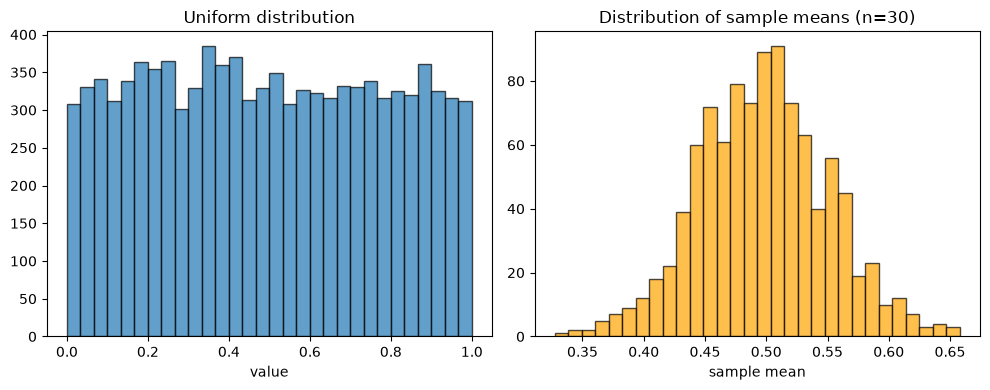

In [19]:
# a) 10,000 uniform numbers (for the left histogram)
pop = np.random.uniform(0, 1, size=10000)

# b) 1000 fresh samples of size 30 — new uniforms each trial
sample_means = []
for _ in range(1000):
    sample = np.random.uniform(0, 1, size=30)
    sample_means.append(np.mean(sample))

sample_means = np.array(sample_means)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(pop, bins=30, edgecolor="black", alpha=0.7)
axes[0].set_title("Uniform distribution")
axes[0].set_xlabel("value")

axes[1].hist(sample_means, bins=30, edgecolor="black", alpha=0.7, color="orange")
axes[1].set_title("Distribution of sample means (n=30)")
axes[1].set_xlabel("sample mean")

plt.tight_layout()
plt.show()
